Importing Libaries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

Load Dataset

In [2]:
df = pd.read_csv('Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
df.drop('No',axis=1, inplace=True)

In [4]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [6]:
df.isnull().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

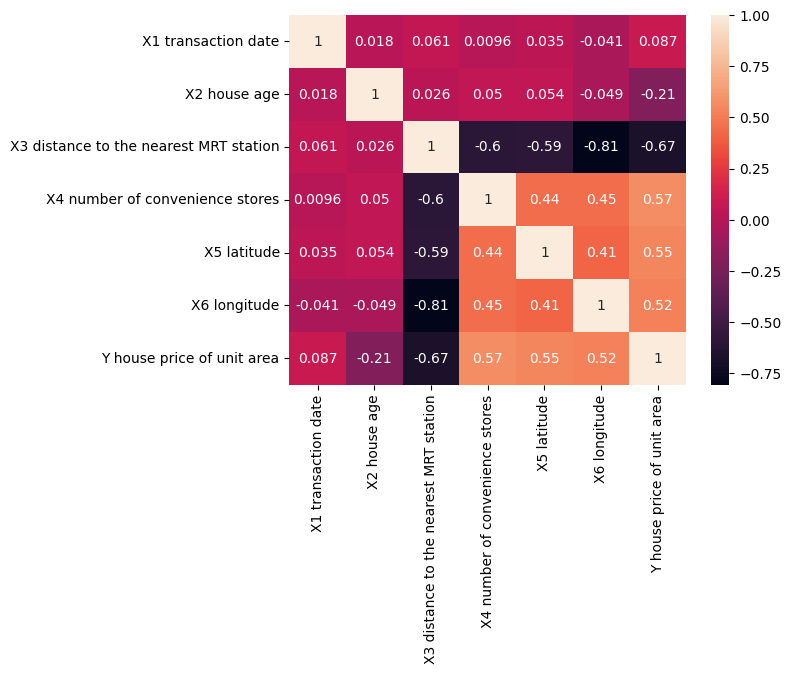

In [7]:
sns.heatmap(df.corr(), annot=True)
plt.show()

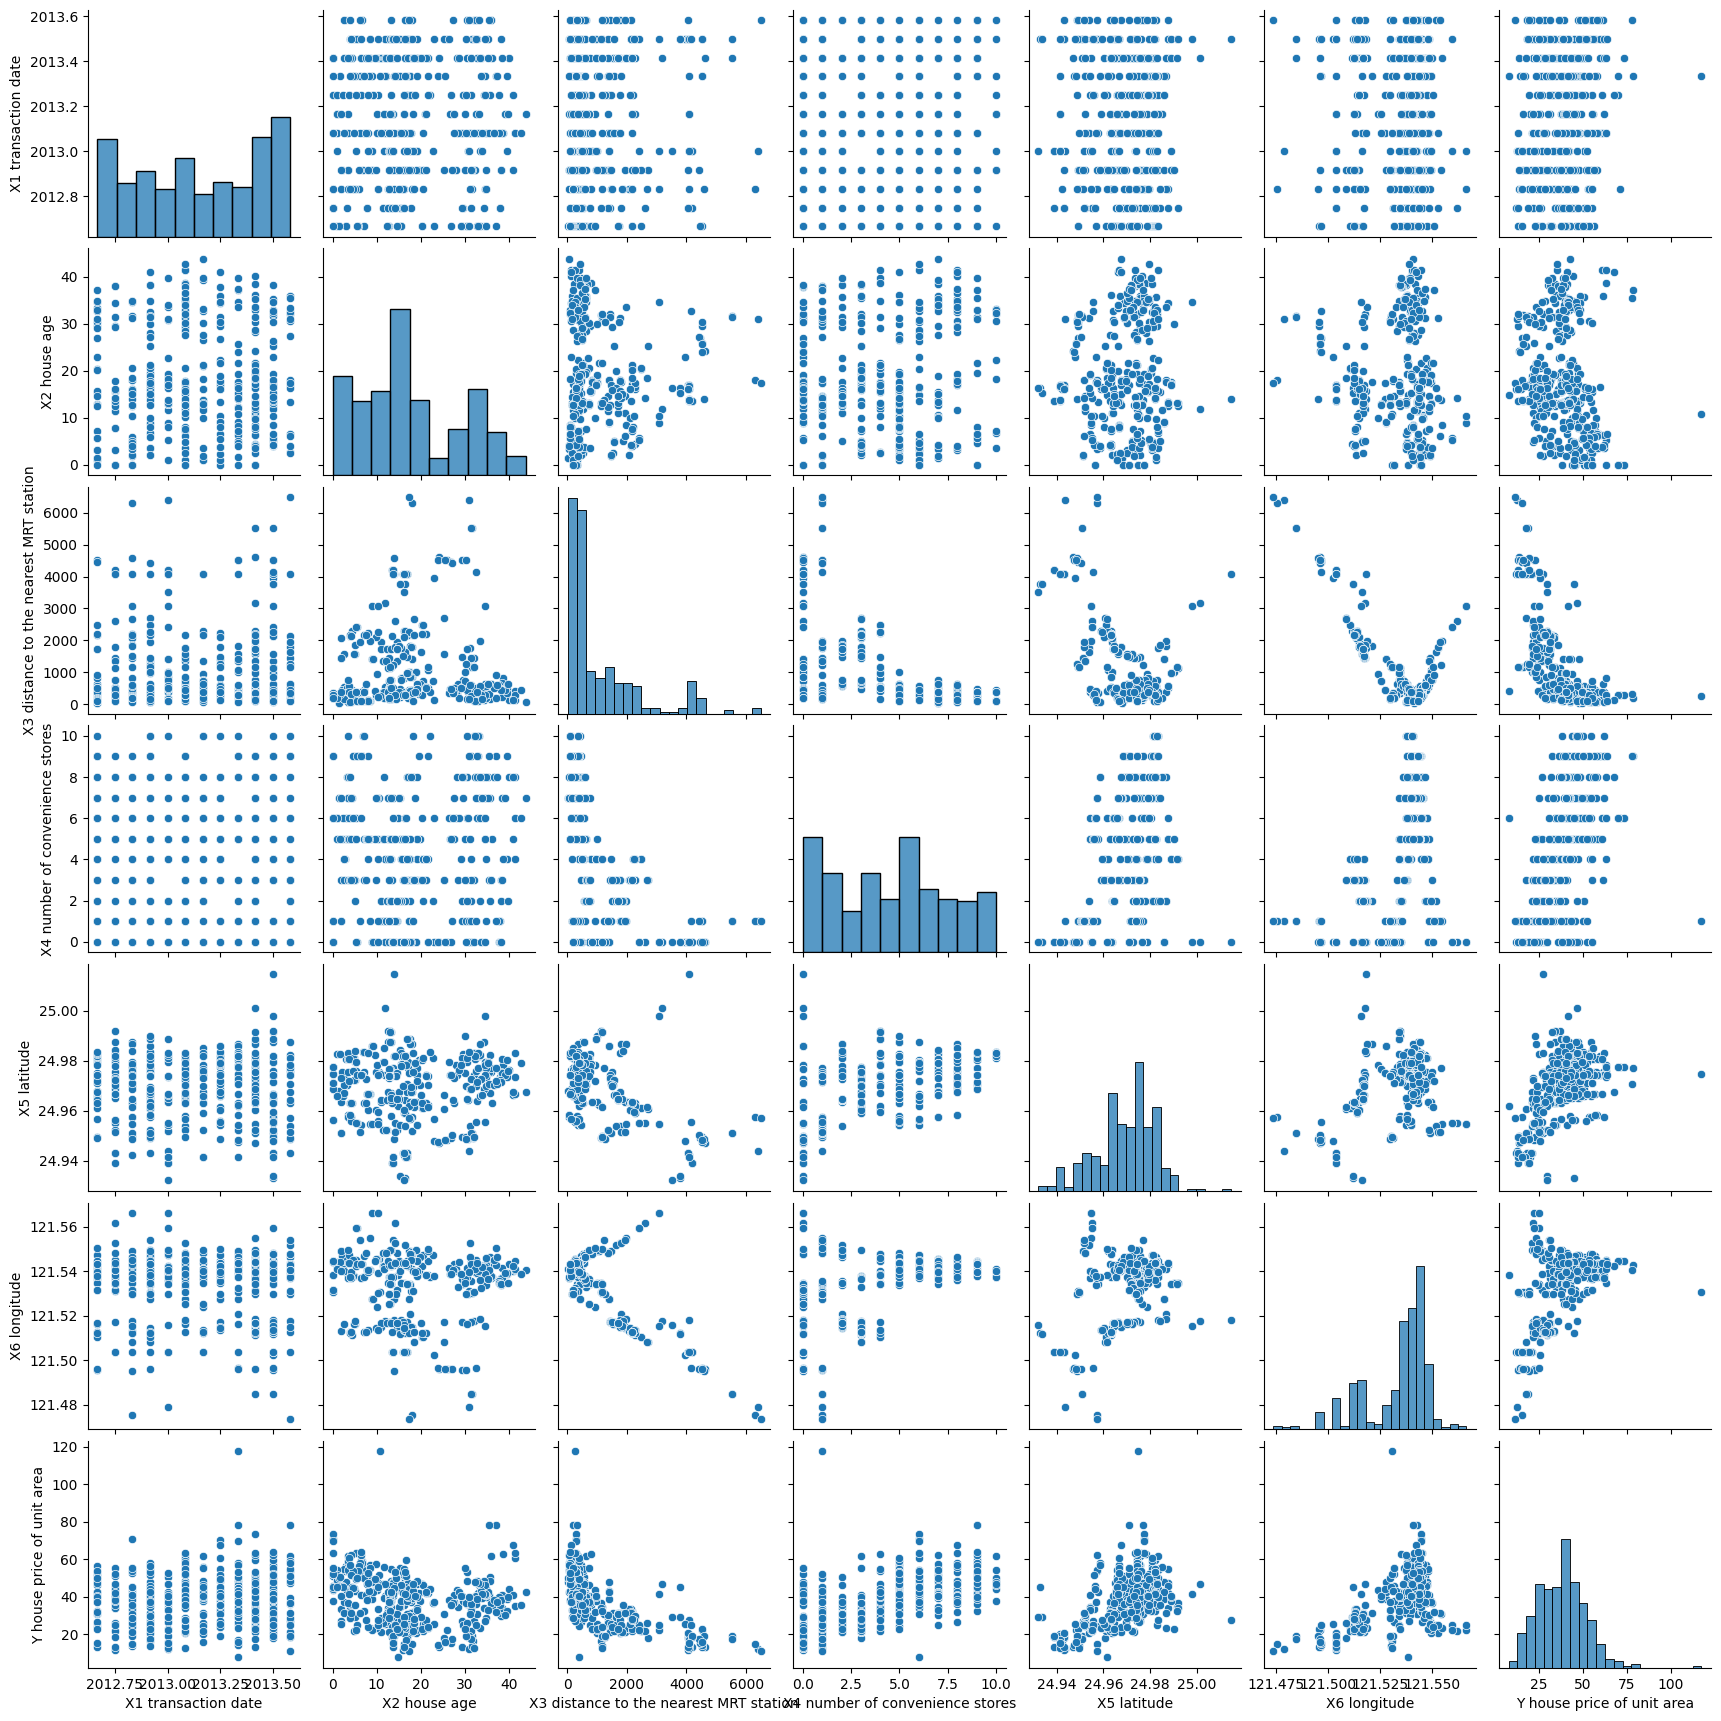

In [8]:
sns.pairplot(df)
plt.show()

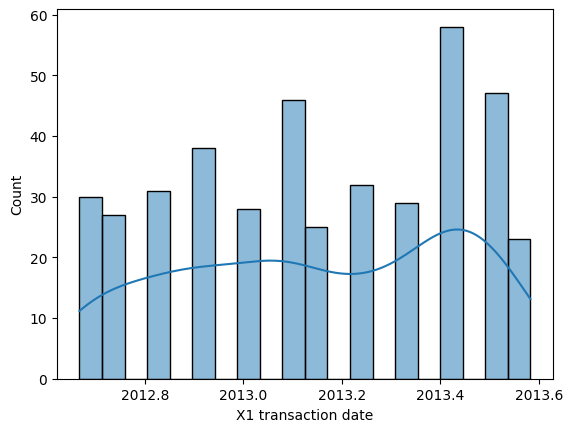

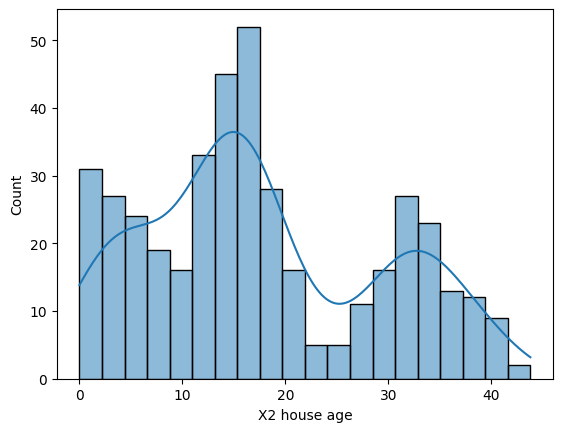

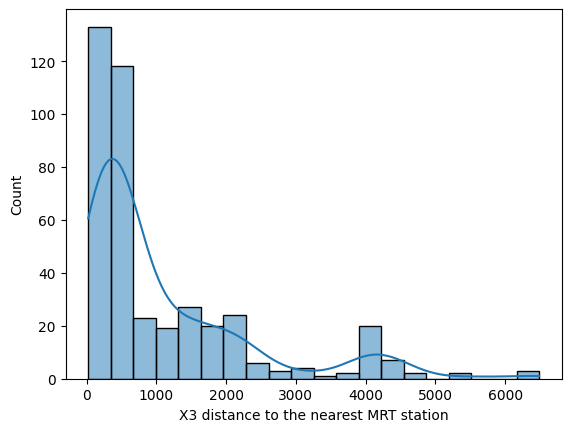

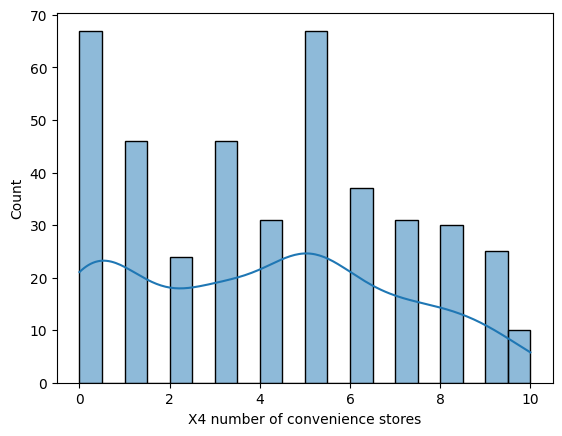

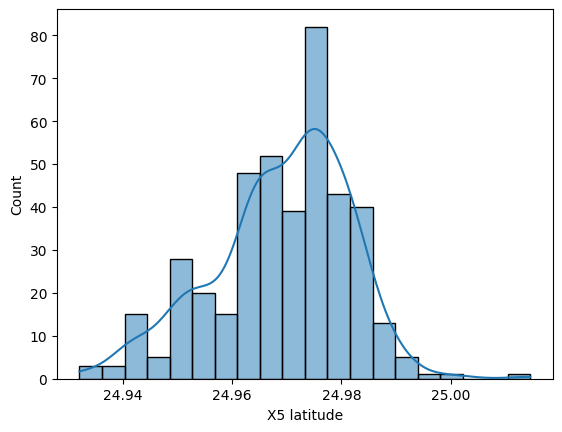

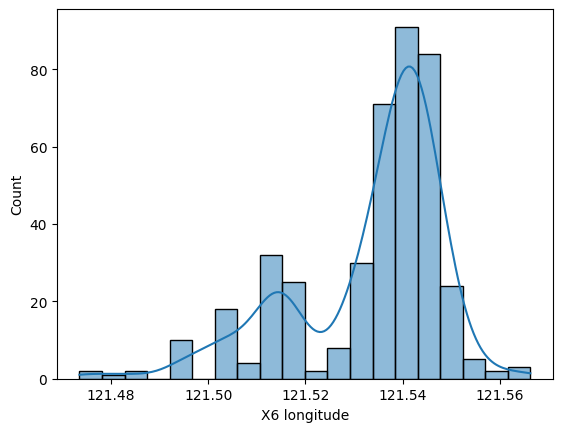

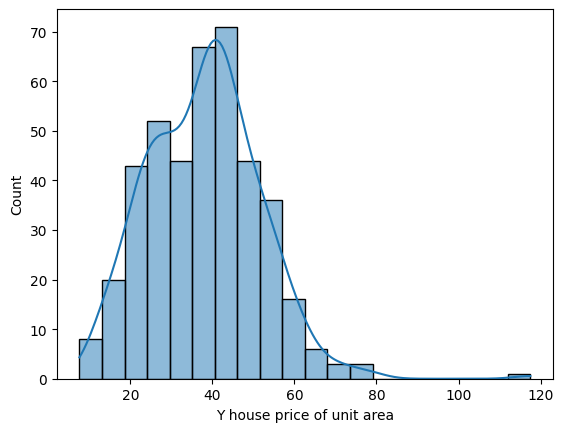

In [9]:
for i in df.columns:
    sns.histplot(df[i], kde=True, bins=20)
    plt.show()

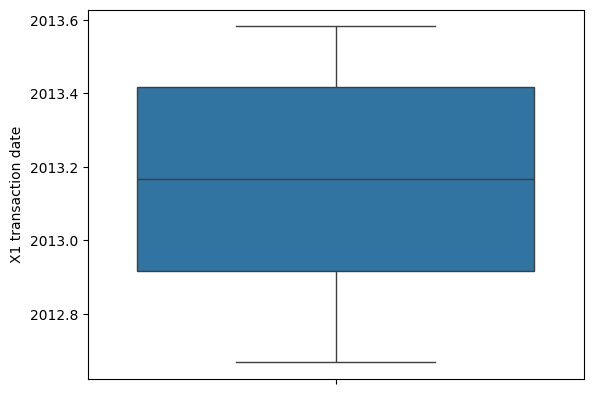

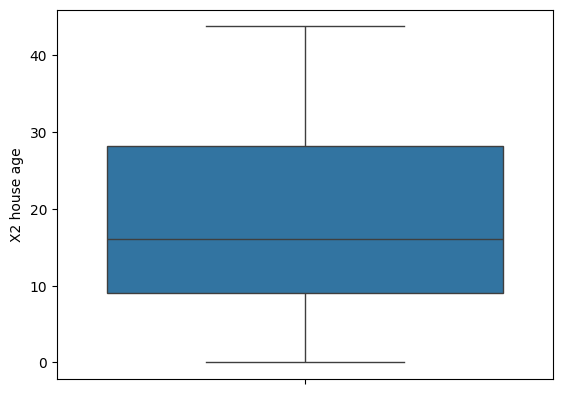

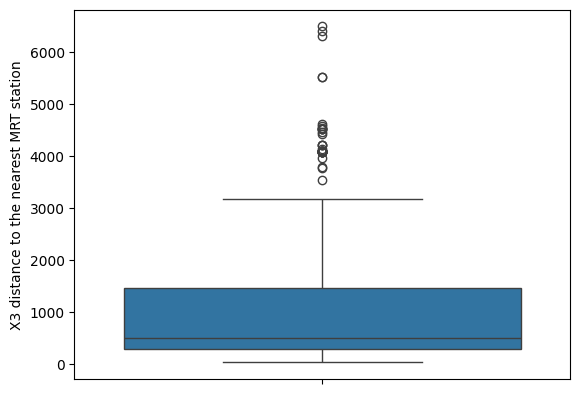

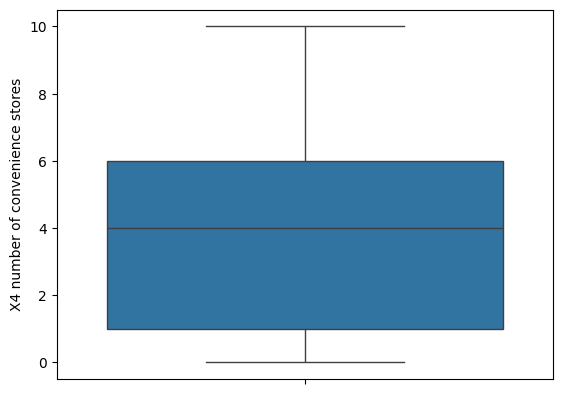

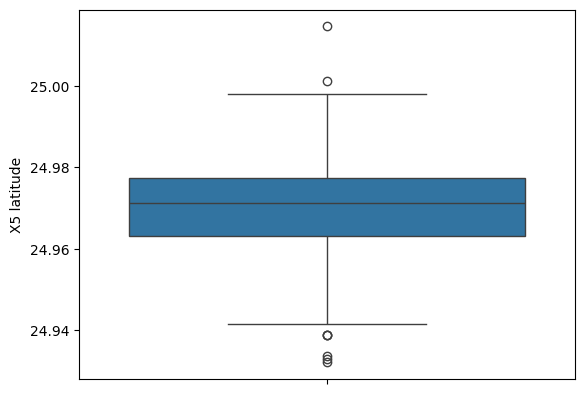

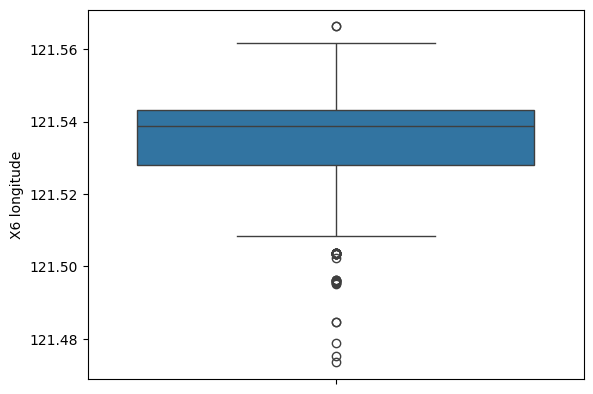

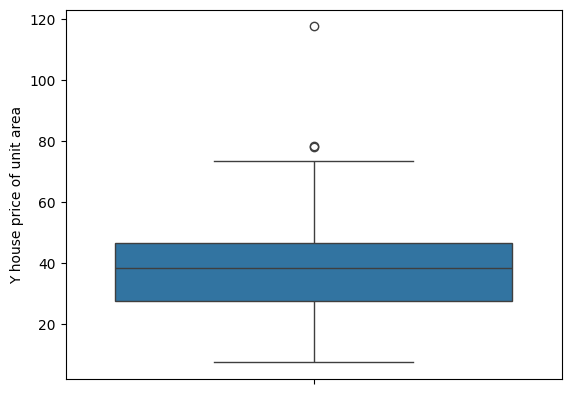

In [10]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

In [11]:
df.head(5)

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [12]:
for i in df.columns:
    print(df[i].unique())
    print(df[i].value_counts())
    print("-----------------------------------------------------")

[2012.917 2013.583 2013.5   2012.833 2012.667 2013.417 2013.083 2013.333
 2013.25  2012.75  2013.    2013.167]
X1 transaction date
2013.417    58
2013.500    47
2013.083    46
2012.917    38
2013.250    32
2012.833    31
2012.667    30
2013.333    29
2013.000    28
2012.750    27
2013.167    25
2013.583    23
Name: count, dtype: int64
-----------------------------------------------------
[32.  19.5 13.3  5.   7.1 34.5 20.3 31.7 17.9 34.8  6.3 13.  20.4 13.2
 35.7  0.  17.7 16.9  1.5  4.5 10.5 14.7 10.1 39.6 29.3  3.1 10.4 19.2
 25.9 29.6 37.9 16.5 15.4 13.9 12.  16.2 13.6 16.8 36.1 34.4  2.7 36.6
 21.7 35.9 24.2 29.4 31.3 32.1 16.1 33.6  3.5 30.3 11.   5.3 17.2  2.6
 17.5 40.1  1.   8.5 30.4 12.5  6.6 35.5 32.5 13.8  6.8 12.3 20.5 38.2
 18.  11.8 30.8 25.3 15.1  1.8  8.9 23.   9.1 20.6 31.9 40.9  8.   6.4
 28.4 16.4 12.7  1.1 32.7 12.2 31.4  4.   8.1 33.3  9.9 14.8 30.6 30.9
 16.6 31.5 38.6  3.8 41.3 38.5 26.6 33.4 18.9 11.4 10.  12.9  5.1 19.8
 11.9  2.1  3.2 34.9 35.8  4.9  6.5 30.7 

In [13]:
df.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [14]:
X = df.drop(['X1 transaction date','Y house price of unit area'], axis=1)
y = df['Y house price of unit area']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(X=x_train, y=y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_predict = lr.predict(X=x_test)

In [19]:
print("R2Score:",r2_score(y_true=y_test, y_pred=y_predict))
print("MSE Score:",mean_squared_error(y_true=y_test, y_pred=y_predict))
print("RMSE Score:",root_mean_squared_error(y_true=y_test, y_pred=y_predict))
print("MAE Score:",mean_absolute_error(y_true=y_test, y_pred=y_predict))

R2Score: 0.4759419191393194
MSE Score: 149.49231368013605
RMSE Score: 12.226704939603968
MAE Score: 6.793135145965632


Ridge Regression

In [20]:
from sklearn.linear_model import Lasso, Ridge

In [21]:
ridge_lr = Ridge(alpha=100, tol=0.0001, random_state=42)
ridge_lr.fit(X=x_train, y=y_train)
y_predict = ridge_lr.predict(X=x_test)
print("R2Score:",r2_score(y_true=y_test, y_pred=y_predict))
print("MSE Score:",mean_squared_error(y_true=y_test, y_pred=y_predict))
print("RMSE Score:",root_mean_squared_error(y_true=y_test, y_pred=y_predict))
print("MAE Score:",mean_absolute_error(y_true=y_test, y_pred=y_predict))

R2Score: 0.44973029133828557
MSE Score: 156.96941789511874
RMSE Score: 12.528743667867051
MAE Score: 7.1241476016209715


Lasso Regression

In [22]:
lasso_lr = Lasso(alpha=100, tol=0.0001, random_state=42)
lasso_lr.fit(X=x_train, y=y_train)
y_predict = lasso_lr.predict(X=x_test)
print("R2Score:",r2_score(y_true=y_test, y_pred=y_predict))
print("MSE Score:",mean_squared_error(y_true=y_test, y_pred=y_predict))
print("RMSE Score:",root_mean_squared_error(y_true=y_test, y_pred=y_predict))
print("MAE Score:",mean_absolute_error(y_true=y_test, y_pred=y_predict))

R2Score: 0.396965309101347
MSE Score: 172.02110694251692
RMSE Score: 13.115681718558015
MAE Score: 7.877762779033722
